# Context-Aware Political Reddit Classification (CNN-LSTM)

Improvement project over the Shirley Cheng (Stanford CS224N) baseline.
Core idea: enrich short Reddit comments with their parent post text using a `[SEP]` marker, embed with CBOW Word2Vec trained on the in-domain training corpus, and classify with a CNN-LSTM in Keras.

**Labels:** 0 = Democrat, 1 = Republican.


## 1. Imports, Config, and Reproducibility


In [1]:
import tensorflow as tf

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TF: 2.15.0
GPU: []


In [2]:
import os
import random
import pickle
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D, LSTM, Dense,
    Dropout, SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
)

for resource in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(resource, quiet=True)
    except Exception as e:
        print(f'Failed to download {resource}: {e}')


In [ ]:
SEED = 42

def set_global_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

set_global_seeds(SEED)

CONFIG = {
    'DATA_PATH': str(Path.cwd() / 'data' / 'political_reddit_context_100k.csv'),
    'ARTIFACTS_DIR': 'artifacts',
    'SEP_TOKEN': '[SEP]',
    'SEP_PLACEHOLDER': 'xxsepxx',
    'MAX_LEN': 200,
    'EMBED_DIM': 100,
    'W2V_WINDOW': 5,
    'W2V_MIN_COUNT': 2,
    'W2V_EPOCHS': 10,
    'W2V_SG': 0,           # CBOW (sg=0)
    'BATCH_SIZE': 64,
    'EPOCHS': 30,
    'LR': 0.001,
    'CONV_FILTERS': 128,
    'KERNEL_SIZE': 5,
    'POOL_SIZE': 2,
    'LSTM_UNITS': 128,
    'DROPOUT': 0.3,
    'SPATIAL_DROPOUT': 0.2,
    'PATIENCE_ES': 4,
    'PATIENCE_LR': 2,
    'TEST_SIZE': 0.10,
    'VAL_SIZE_OF_REMAINDER': 1.0 / 9.0,
    'SEED': SEED,
}


TensorFlow: 2.15.0
GPUs: []
Seed: 42
Artifacts dir: d:\PROJECTS\NLP - PROJECT\artifacts


## 2. Data Loading


In [4]:
df = pd.read_csv(
    CONFIG['DATA_PATH'],
    dtype={'id': str, 'root': str, 'reply_to': str},
)
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nFirst rows:')
df.head()


Shape: (100000, 5)

Dtypes:
id          object
root        object
reply_to    object
text        object
label        int64
dtype: object

First rows:


,id,root,reply_to,text,label
0,e0icvw4,8q9bva,e0iaqq4,Do you consider CNN to be?,1
1,cwywp2l,3skvz0,cwyw88z,Where did the liberal touch you? \n\nShow me ...,1
2,d9xj9u3,5ck8j0,5ck8j0,We do need to apologize for some things. The ...,0
3,dwiox1t,881zb4,dwhlw01,My old high school had a bunch of pickup truck...,1
4,c6iviy1,10zuhi,c6i9vp6,You can...until you can't. What you're describ...,1


## 3. Dataset Integrity Checks


Label values: [0, 1]

Class counts:
label
1    50000
0    50000
Name: count, dtype: int64

Null counts per column:
id             0
root           0
reply_to    1129
text           0
label          0
dtype: int64

[deleted] in text: 0
[removed] in text: 0

Duplicate ids: 0

Character-length stats per class:
         count       mean         std  min   25%    50%    75%      max
label                                                                  
0      50000.0  270.96002  492.701436  3.0  59.0  132.0  296.0  20511.0
1      50000.0  318.31910  478.400296  3.0  77.0  167.0  366.0  13178.0


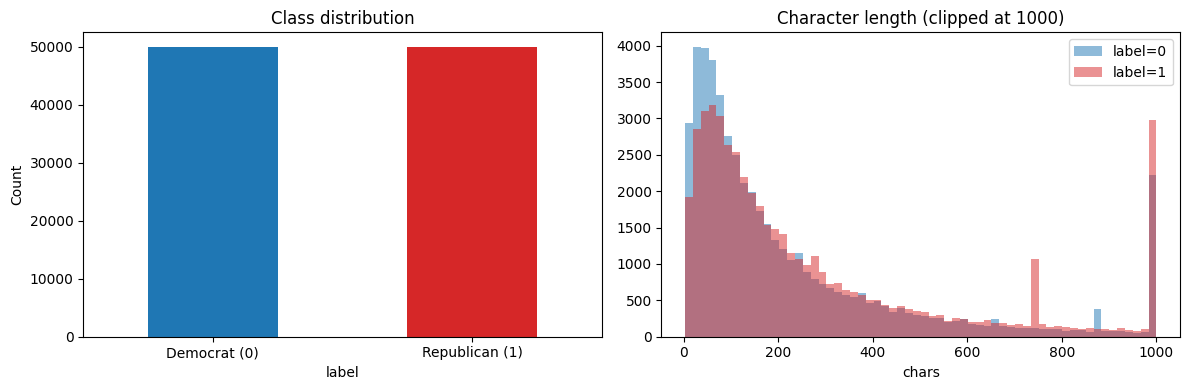

In [5]:
required = {'text', 'label', 'id', 'root', 'reply_to'}
missing = required - set(df.columns)
assert not missing, f'Missing columns: {missing}'

df['label'] = df['label'].astype(int)
print('Label values:', sorted(df['label'].unique()))
assert set(df['label'].unique()) == {0, 1}

print('\nClass counts:')
print(df['label'].value_counts())

print('\nNull counts per column:')
print(df.isnull().sum())

deleted_count = (df['text'] == '[deleted]').sum()
removed_count = (df['text'] == '[removed]').sum()
print(f'\n[deleted] in text: {deleted_count}')
print(f'[removed] in text: {removed_count}')

dup_ids = df['id'].duplicated().sum()
print(f'\nDuplicate ids: {dup_ids}')

df['char_len'] = df['text'].astype(str).str.len()
print('\nCharacter-length stats per class:')
print(df.groupby('label')['char_len'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['tab:blue', 'tab:red']
)
axes[0].set_xticklabels(['Democrat (0)', 'Republican (1)'], rotation=0)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
    axes[1].hist(
        df.loc[df['label'] == lbl, 'char_len'].clip(upper=1000),
        bins=60, alpha=0.5, label=f'label={lbl}', color=color,
    )
axes[1].set_title('Character length (clipped at 1000)')
axes[1].legend()
axes[1].set_xlabel('chars')
plt.tight_layout()
plt.show()


## 4. Context Matching Logic


In [6]:
def is_main_post(row):
    return (row['id'] == row['root']) or pd.isna(row['reply_to'])

def is_usable_text(t):
    if not isinstance(t, str):
        return False
    s = t.strip()
    if s == '' or s == '[deleted]' or s == '[removed]':
        return False
    return True

main_post_mask = df.apply(is_main_post, axis=1) & df['text'].apply(is_usable_text)
posts_df = df[main_post_mask]
print(f'Total rows:           {len(df)}')
print(f'Candidate main posts: {len(posts_df)}')

posts_context = {}
conflicts = 0
for pid, txt in zip(posts_df['id'].tolist(), posts_df['text'].tolist()):
    if pid in posts_context:
        conflicts += 1
        continue
    posts_context[pid] = txt
print(f'\nposts_context size:   {len(posts_context)}')
print(f'Conflicts skipped:    {conflicts}')

with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'posts_context.pkl'), 'wb') as f:
    pickle.dump(posts_context, f)

rng = random.Random(SEED)
if len(posts_context) >= 3:
    sample_keys = rng.sample(list(posts_context.keys()), 3)
    for k in sample_keys:
        print(f'\nid={k}')
        print(f'text={posts_context[k][:200]!r}')


Total rows:           100000
Candidate main posts: 1129

posts_context size:   1129
Conflicts skipped:    0

id=lmsye
text="Just a ponderance... kindly humor me?\n\nIf the two tempers could remain civil at all times and brilliant thoughts could prevail...\n\nCould a Paul/Sander's or a Sander's/Paul ticket ever be pulled off? I"

id=sv3xi
text="I want to be republican but I really can't support the leadership in place when they so blatantly are favor givers and in peoples pockets. I'm not assuming the democrats are much better but seriously "

id=8ddyoa
text='Up until recently, this type of technology was always 30 years away, but recently [MIT figured out way to make sheets of it] (http://news.mit.edu/2018/manufacturing-graphene-rolls-ultrathin-membranes-'


In [7]:
# Context hit rate analysis (overall and per class)
is_comment = df['id'] != df['root']
df_comments = df[is_comment].copy()
df_comments['context_found'] = df_comments['root'].isin(posts_context)

overall_hit = df_comments['context_found'].mean()
per_class_hit = df_comments.groupby('label')['context_found'].mean()

print(f'Comments total:        {len(df_comments)}')
print(f'Overall context hit:   {overall_hit:.4f}')
print('\nPer-class hit rate:')
print(per_class_hit)


Comments total:        98871
Overall context hit:   0.0233

Per-class hit rate:
label
0    0.019069
1    0.027443
Name: context_found, dtype: float64


## 5. Context Enrichment


In [8]:
SEP_PLACEHOLDER = CONFIG['SEP_PLACEHOLDER']

def build_enriched(row):
    txt = row['text'] if isinstance(row['text'], str) else ''
    if row['id'] == row['root']:
        return txt, False  # the row itself is a top-level post
    parent = posts_context.get(row['root'])
    if parent is None:
        return txt, False  # fallback: comment-only
    return parent + ' ' + SEP_PLACEHOLDER + ' ' + txt, True

results = df.apply(build_enriched, axis=1)
df['enriched_text'] = [r[0] for r in results]
df['has_context']  = [r[1] for r in results]

print('has_context distribution:')
print(df['has_context'].value_counts())
print('\nMean has_context per label:')
print(df.groupby('label')['has_context'].mean())

print('\n=== Sample enriched rows (has_context=True) ===')
ex = df[df['has_context']].sample(3, random_state=SEED)
for _, row in ex.iterrows():
    print('\n---')
    print('LABEL   :', row['label'])
    print('ENRICHED:', row['enriched_text'][:400])

print('\n=== Sample fallback rows (has_context=False, not a post) ===')
fallback = df[(~df['has_context']) & (df['id'] != df['root'])]
if len(fallback) > 0:
    for _, row in fallback.sample(min(3, len(fallback)), random_state=SEED).iterrows():
        print('\n---')
        print('LABEL   :', row['label'])
        print('TEXT    :', row['enriched_text'][:400])


has_context distribution:
has_context
False    97699
True      2301
Name: count, dtype: int64

Mean has_context per label:
label
0    0.01878
1    0.02724
Name: has_context, dtype: float64

=== Sample enriched rows (has_context=True) ===

---
LABEL   : 0
ENRICHED: Sen. Sanders has some very ambitious policies he wants to acomplish, healthcare, $15 an hour Min. wage, ending Citizens united and dark money,....

And all of them are very popular among all democrats. But to accomplish those things and quite frankly to overcome the institutional  bias in the Democratic party to get elected...he needs to increase voter turn out. And I will argue he has done just t

---
LABEL   : 1
ENRICHED: Please read before downvoting (it's a self-anyways, just want more people to answer (more opinions))

The Scandinavian countries have the smallest gap between the upper-low class (in the western world). They work like we (Canada) and you (US) do on a progressive taxing system, only they have a 'billionaire

## 6. Preprocessing Pipeline

Order: tokenize → lowercase → stopword removal → stemming. The `[SEP]` marker is replaced with a stem-proof placeholder (`xxsepxx`) before tokenization so the stemmer and stopword filter cannot mutate or delete it.


In [9]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
PLACEHOLDER = CONFIG['SEP_PLACEHOLDER']
SEP_TOKEN = CONFIG['SEP_TOKEN']

def preprocess(text):
    if not isinstance(text, str):
        return []
    # 1) Protect the SEP marker
    text = text.replace(SEP_TOKEN, ' ' + PLACEHOLDER + ' ')
    # 2) Tokenize
    tokens = word_tokenize(text)
    # 3) Lowercase
    tokens = [t.lower() for t in tokens]
    # 4) Stopword removal (preserve placeholder)
    tokens = [t for t in tokens if (t == PLACEHOLDER) or (t not in stop_words)]
    # 5) Stemming (preserve placeholder)
    tokens = [t if t == PLACEHOLDER else stemmer.stem(t) for t in tokens]
    return tokens


In [10]:
try:
    from tqdm.auto import tqdm
    tqdm.pandas(desc='Preprocessing')
    df['tokens'] = df['enriched_text'].progress_apply(preprocess)
except Exception:
    df['tokens'] = df['enriched_text'].apply(preprocess)

df['n_tokens'] = df['tokens'].apply(len)

print('Token-length stats:')
print(df['n_tokens'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

n_empty = int((df['n_tokens'] == 0).sum())
print(f'\nEmpty-token rows: {n_empty}')
if n_empty > 0:
    df = df[df['n_tokens'] > 0].reset_index(drop=True)
    print(f'After dropping empties: {len(df)}')

# Placeholder integrity check
has_ctx = df[df['has_context']]
contains_ph = has_ctx['tokens'].apply(lambda toks: PLACEHOLDER in toks)
print(f'\nhas_context rows:                                  {len(has_ctx)}')
print(f'has_context rows that still contain the placeholder: {int(contains_ph.sum())}')

print('\nSample tokenized rows:')
for i in range(3):
    print(f'\nrow {i} label={df["label"].iloc[i]}')
    print(df['tokens'].iloc[i][:40])


Preprocessing:   0%|          | 0/100000 [00:00<?, ?it/s]

Token-length stats:
count    100000.000000
mean         37.423870
std          68.471544
min           0.000000
50%          18.000000
90%          82.000000
95%         129.000000
99%         294.000000
max        2838.000000
Name: n_tokens, dtype: float64

Empty-token rows: 39
After dropping empties: 99961

has_context rows:                                  2301
has_context rows that still contain the placeholder: 2301

Sample tokenized rows:

row 0 label=1
['consid', 'cnn', '?']

row 1 label=1
['liber', 'touch', '?', 'show', 'constitut', '?', 'free', 'healthcar', '?', 'singl', 'issu', 'voter', 'complex', '?', 'suprem', 'court', 'justic', 'concern', '?']

row 2 label=0
['need', 'apolog', 'thing', '.', 'fact', 'matter', 'alien', 'work', 'class', 'polit', 'system', '.', 'talk', 'polic', 'kill', 'black', ',', 'commit', 'conquer', 'poverti', ',', 'main', 'killer', 'black', 'countri', 'also', 'killer', 'mani', 'work', 'class', 'white', '.', 'hillari', "n't", 'want', 'talk', 'get', 'big', 

## 7. Stratified Train / Validation / Test Split (80 / 10 / 10)


In [11]:
train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG['TEST_SIZE'],
    stratify=df['label'],
    random_state=SEED,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=CONFIG['VAL_SIZE_OF_REMAINDER'],
    stratify=train_val_df['label'],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

n_total = len(train_df) + len(val_df) + len(test_df)
print(f'Train: {len(train_df):>6} ({len(train_df)/n_total:.2%})')
print(f'Val:   {len(val_df):>6} ({len(val_df)/n_total:.2%})')
print(f'Test:  {len(test_df):>6} ({len(test_df)/n_total:.2%})')

print('\nLabel balance per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["label"].value_counts(normalize=True).round(4).to_dict()}')

print('\nhas_context fraction per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["has_context"].mean():.4f}')


Train:  79968 (80.00%)
Val:     9996 (10.00%)
Test:    9997 (10.00%)

Label balance per split:
  train: {1: 0.5001, 0: 0.4999}
  val: {1: 0.5001, 0: 0.4999}
  test: {1: 0.5001, 0: 0.4999}

has_context fraction per split:
  train: 0.0232
  val: 0.0229
  test: 0.0218


## 8. Token-Length Analysis (Train Only) → choose `MAX_LEN`


Train token-length stats:
count    79968.000000
mean        37.318978
std         67.994736
min          1.000000
50%         18.000000
90%         82.000000
95%        129.000000
99%        291.000000
max       2838.000000
Name: n_tokens, dtype: float64

P95: 129   P99: 291

Using MAX_LEN = 129


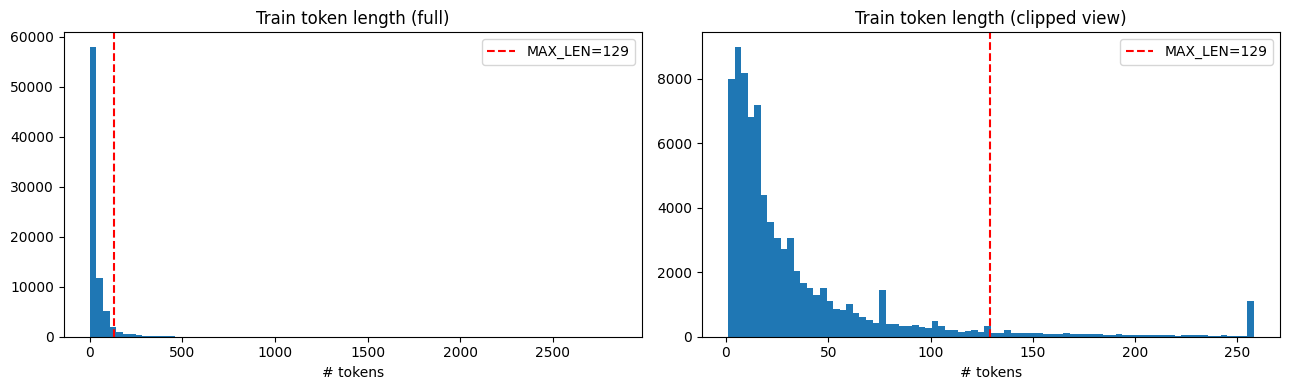

In [12]:
train_lens = train_df['n_tokens']
print('Train token-length stats:')
print(train_lens.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

p95 = int(np.percentile(train_lens, 95))
p99 = int(np.percentile(train_lens, 99))
print(f'\nP95: {p95}   P99: {p99}')

MAX_LEN = int(min(max(p95, 64), 300))
CONFIG['MAX_LEN'] = MAX_LEN
print(f'\nUsing MAX_LEN = {MAX_LEN}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train_lens, bins=80)
axes[0].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[0].set_title('Train token length (full)')
axes[0].set_xlabel('# tokens')
axes[0].legend()

clipped = train_lens.clip(upper=MAX_LEN * 2)
axes[1].hist(clipped, bins=80)
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Train token length (clipped view)')
axes[1].set_xlabel('# tokens')
axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Keras Tokenizer and Padded Sequences

Tokenizer is fit on **train only**. `filters=''` and `lower=False` prevent it from re-stripping the `[SEP]` placeholder or undoing case decisions already made.


In [13]:
train_token_strings = train_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()
val_token_strings   = val_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()
test_token_strings  = test_df['tokens'].apply(lambda toks: ' '.join(toks)).tolist()

tokenizer = Tokenizer(filters='', lower=False, oov_token='<OOV>')
tokenizer.fit_on_texts(train_token_strings)

vocab_size = len(tokenizer.word_index) + 1
print(f'Vocab size (incl. pad+OOV): {vocab_size}')

X_train_seq = tokenizer.texts_to_sequences(train_token_strings)
X_val_seq   = tokenizer.texts_to_sequences(val_token_strings)
X_test_seq  = tokenizer.texts_to_sequences(test_token_strings)

X_train = pad_sequences(X_train_seq, maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')
X_val   = pad_sequences(X_val_seq,   maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=CONFIG['MAX_LEN'], padding='post', truncating='post')

y_train = train_df['label'].values.astype('float32')
y_val   = val_df['label'].values.astype('float32')
y_test  = test_df['label'].values.astype('float32')

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

oov_idx = tokenizer.word_index.get('<OOV>')
def oov_fraction(seqs, oov_id):
    total = sum(len(s) for s in seqs)
    if total == 0 or oov_id is None:
        return 0.0
    oov = sum(1 for s in seqs for i in s if i == oov_id)
    return oov / total

print(f'\nOOV fraction (train): {oov_fraction(X_train_seq, oov_idx):.4f}')
print(f'OOV fraction (val):   {oov_fraction(X_val_seq, oov_idx):.4f}')
print(f'OOV fraction (test):  {oov_fraction(X_test_seq, oov_idx):.4f}')

with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)


Vocab size (incl. pad+OOV): 55200
X_train: (79968, 129)  y_train: (79968,)
X_val:   (9996, 129)    y_val:   (9996,)
X_test:  (9997, 129)   y_test:  (9997,)

OOV fraction (train): 0.0000
OOV fraction (val):   0.0120
OOV fraction (test):  0.0110


## 10. CBOW Word2Vec Training (Train Corpus Only)


In [14]:
train_tokens_list = train_df['tokens'].tolist()
print(f'Sentences for Word2Vec: {len(train_tokens_list)}')

w2v = Word2Vec(
    sentences=train_tokens_list,
    vector_size=CONFIG['EMBED_DIM'],
    window=CONFIG['W2V_WINDOW'],
    min_count=CONFIG['W2V_MIN_COUNT'],
    workers=4,
    sg=CONFIG['W2V_SG'],   # 0 = CBOW (required)
    epochs=CONFIG['W2V_EPOCHS'],
    seed=SEED,
)
assert CONFIG['W2V_SG'] == 0, 'CBOW is mandatory'

print(f'W2V vocab size: {len(w2v.wv)}')
w2v.save(os.path.join(CONFIG['ARTIFACTS_DIR'], 'w2v_cbow.model'))

probe_words = ['trump', 'biden', 'tax', 'gun', 'liber', 'conserv', PLACEHOLDER]
for w in probe_words:
    if w in w2v.wv:
        print(f"\nNearest to '{w}':")
        for sim_word, score in w2v.wv.most_similar(w, topn=5):
            print(f'  {sim_word:>20s}  {score:.3f}')
    else:
        print(f"\n'{w}' not in W2V vocab")


Sentences for Word2Vec: 79968
W2V vocab size: 23335

Nearest to 'trump':
                 putin  0.523
                  cruz  0.501
               clinton  0.485
                    mc  0.479
                  penc  0.478

Nearest to 'biden':
                    vp  0.722
             elizabeth  0.712
                warren  0.707
                   joe  0.674
                  kain  0.674

Nearest to 'tax':
                deduct  0.570
               loophol  0.567
                 taxat  0.566
                taxabl  0.531
               benefit  0.521

Nearest to 'gun':
               firearm  0.696
               handgun  0.570
                  rifl  0.536
             ownership  0.524
                pistol  0.522

Nearest to 'liber':
               conserv  0.776
                left-w  0.603
             conservat  0.557
              centrist  0.556
             socialist  0.554

Nearest to 'conserv':
                 liber  0.776
             conservat  0.728
           lib

## 11. Embedding Matrix Construction


In [15]:
embedding_matrix = np.zeros((vocab_size, CONFIG['EMBED_DIM']), dtype='float32')
hits = 0
for word, idx in tokenizer.word_index.items():
    if word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        hits += 1

embedding_matrix[0] = 0.0  # padding row stays zero

coverage = hits / max(vocab_size - 1, 1)
print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'W2V coverage:           {coverage:.4f} ({hits}/{vocab_size - 1})')

np.save(os.path.join(CONFIG['ARTIFACTS_DIR'], 'embedding_matrix.npy'), embedding_matrix)

assert embedding_matrix.shape == (vocab_size, CONFIG['EMBED_DIM'])
assert np.all(embedding_matrix[0] == 0.0)


Embedding matrix shape: (55200, 100)
W2V coverage:           0.4227 (23335/55199)


## 12. CNN-LSTM Model Definition

Architecture: `Embedding (W2V init, trainable) → SpatialDropout1D → Conv1D → MaxPooling1D → LSTM → Dropout → Dense(sigmoid)`.


In [16]:
def build_cnn_lstm(vocab_size, embed_dim, max_len, embedding_matrix, config):
    inp = Input(shape=(max_len,), name='input_ids')
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True,
        mask_zero=False,
        name='embedding',
    )(inp)
    x = SpatialDropout1D(config['SPATIAL_DROPOUT'])(x)
    x = Conv1D(
        filters=config['CONV_FILTERS'],
        kernel_size=config['KERNEL_SIZE'],
        padding='same',
        activation='relu',
        name='conv1d',
    )(x)
    x = MaxPooling1D(pool_size=config['POOL_SIZE'], name='maxpool')(x)
    x = LSTM(
        config['LSTM_UNITS'],
        dropout=0.2,
        recurrent_dropout=0.0,
        name='lstm',
    )(x)
    x = Dropout(config['DROPOUT'])(x)
    out = Dense(1, activation='sigmoid', name='output')(x)
    return Model(inp, out, name='cnn_lstm')

model = build_cnn_lstm(
    vocab_size=vocab_size,
    embed_dim=CONFIG['EMBED_DIM'],
    max_len=CONFIG['MAX_LEN'],
    embedding_matrix=embedding_matrix,
    config=CONFIG,
)
model.compile(
    optimizer=Adam(learning_rate=CONFIG['LR']),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.summary()




Model: "cnn_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_ids (InputLayer)      [(None, 129)]             0         
                                                                 
 embedding (Embedding)       (None, 129, 100)          5520000   
                                                                 
 spatial_dropout1d (Spatial  (None, 129, 100)          0         
 Dropout1D)                                                      
                                                                 
 conv1d (Conv1D)             (None, 129, 128)          64128     
                                                                 
 maxpool (MaxPooling1D)      (None, 64, 128)           0         
                                                                 
 lstm (LSTM)                 (None, 128)               131584    
                                                        

## 13. Training Callbacks


In [17]:
best_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'best_model.keras')

callbacks = [
    ModelCheckpoint(
        filepath=best_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=CONFIG['PATIENCE_ES'],
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['PATIENCE_LR'],
        min_lr=1e-5,
        verbose=1,
    ),
]
print(f'Best model will be saved to: {best_path}')


Best model will be saved to: artifacts\best_model.keras


## 14. Model Training


In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG['EPOCHS'],
    batch_size=CONFIG['BATCH_SIZE'],
    callbacks=callbacks,
    shuffle=True,
    verbose=2,
)

hist_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'history.json')
with open(hist_path, 'w') as f:
    json.dump(
        {k: [float(x) for x in v] for k, v in history.history.items()},
        f, indent=2,
    )

print(f'\nTrained for {len(history.history["loss"])} epochs')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')


Epoch 1/30



Epoch 1: val_accuracy improved from -inf to 0.65896, saving model to artifacts\best_model.keras
1250/1250 - 90s - loss: 0.6558 - accuracy: 0.5959 - val_loss: 0.6176 - val_accuracy: 0.6590 - lr: 0.0010 - 90s/epoch - 72ms/step
Epoch 2/30

Epoch 2: val_accuracy improved from 0.65896 to 0.67387, saving model to artifacts\best_model.keras
1250/1250 - 86s - loss: 0.6013 - accuracy: 0.6641 - val_loss: 0.5853 - val_accuracy: 0.6739 - lr: 0.0010 - 86s/epoch - 69ms/step
Epoch 3/30

Epoch 3: val_accuracy improved from 0.67387 to 0.67587, saving model to artifacts\best_model.keras
1250/1250 - 87s - loss: 0.5726 - accuracy: 0.6891 - val_loss: 0.5830 - val_accuracy: 0.6759 - lr: 0.0010 - 87s/epoch - 70ms/step
Epoch 4/30

Epoch 4: val_accuracy improved from 0.67587 to 0.67997, saving model to artifacts\best_model.keras
1250/1250 - 85s - loss: 0.5419 - accuracy: 0.7177 - val_loss: 0.5842 - val_accuracy: 0.6800 - lr: 0.0010 - 85s/epoch - 68ms/step
Epoch 5/30

Epoch 5: val_accuracy did not

## 15. Training & Validation Curves


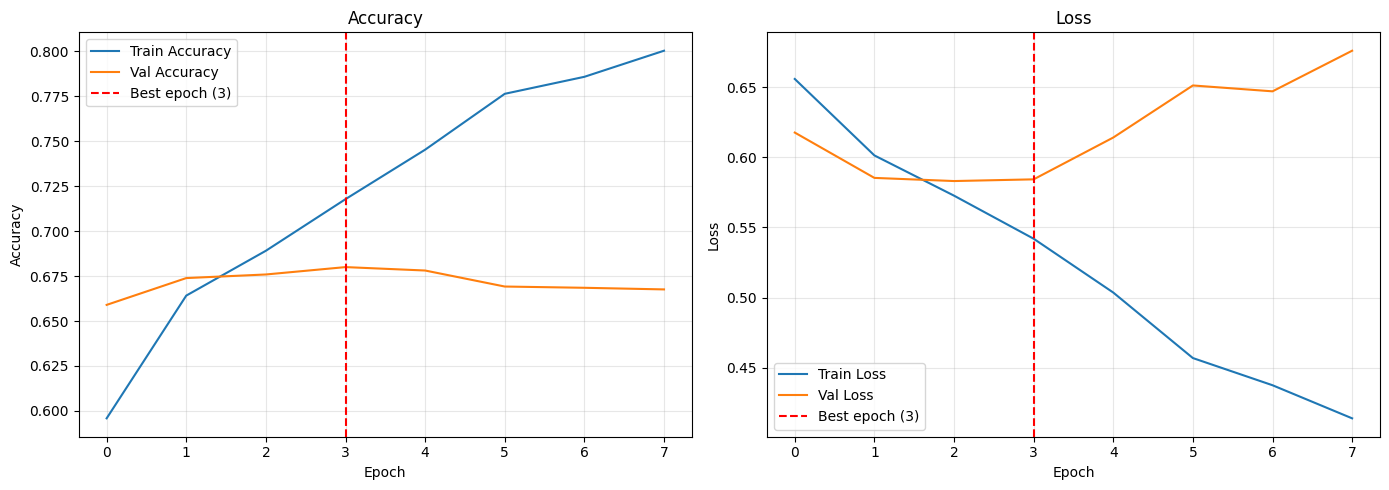

In [19]:
hist = history.history
best_ep = int(np.argmax(hist['val_accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['accuracy'], label='Train Accuracy')
axes[0].plot(hist['val_accuracy'], label='Val Accuracy')
axes[0].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist['loss'], label='Train Loss')
axes[1].plot(hist['val_loss'], label='Val Loss')
axes[1].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 16. Final Test Evaluation


In [20]:
best_model = load_model(best_path)

y_prob = best_model.predict(X_test, batch_size=CONFIG['BATCH_SIZE'], verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = y_test.astype(int)

acc        = accuracy_score(y_true, y_pred)
prec_rep   = precision_score(y_true, y_pred, pos_label=1)
rec_rep    = recall_score(y_true, y_pred, pos_label=1)
f1_rep     = f1_score(y_true, y_pred, pos_label=1)
prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro  = recall_score(y_true, y_pred, average='macro')
f1_macro   = f1_score(y_true, y_pred, average='macro')

print(f'Test Accuracy:           {acc:.4f}')
print(f'Test Precision (Rep):    {prec_rep:.4f}')
print(f'Test Recall    (Rep):    {rec_rep:.4f}')
print(f'Test F1        (Rep):    {f1_rep:.4f}')
print(f'Test Precision (macro):  {prec_macro:.4f}')
print(f'Test Recall    (macro):  {rec_macro:.4f}')
print(f'Test F1        (macro):  {f1_macro:.4f}')

print('\nClassification report:')
print(classification_report(
    y_true, y_pred,
    target_names=['Democrat', 'Republican'],
    digits=4,
))

results = {
    'accuracy': float(acc),
    'precision_republican': float(prec_rep),
    'recall_republican':    float(rec_rep),
    'f1_republican':        float(f1_rep),
    'precision_macro':      float(prec_macro),
    'recall_macro':         float(rec_macro),
    'f1_macro':             float(f1_macro),
    'n_test':               int(len(y_true)),
    'max_len':              int(CONFIG['MAX_LEN']),
    'vocab_size':           int(vocab_size),
}
with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'test_metrics.json'), 'w') as f:
    json.dump(results, f, indent=2)


157/157 [==============================] - 3s 15ms/step
Test Accuracy:           0.6823
Test Precision (Rep):    0.7074
Test Recall    (Rep):    0.6219
Test F1        (Rep):    0.6619
Test Precision (macro):  0.6850
Test Recall    (macro):  0.6823
Test F1        (macro):  0.6811

Classification report:
              precision    recall  f1-score   support

    Democrat     0.6626    0.7427    0.7004      4998
  Republican     0.7074    0.6219    0.6619      4999

    accuracy                         0.6823      9997
   macro avg     0.6850    0.6823    0.6811      9997
weighted avg     0.6850    0.6823    0.6811      9997



## 17. Confusion Matrix Visualization


Confusion matrix (rows = true, cols = predicted):
[[3712 1286]
 [1890 3109]]


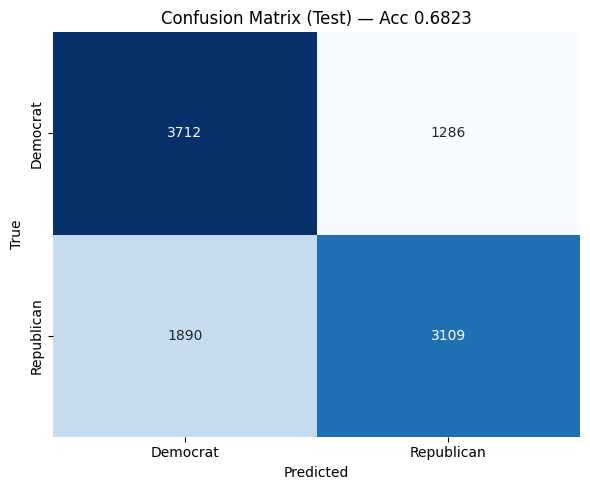

In [21]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix (rows = true, cols = predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Democrat', 'Republican'],
    yticklabels=['Democrat', 'Republican'],
    ax=ax, cbar=False,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test) — Acc {acc:.4f}')
plt.tight_layout()
plt.show()


## 18. Error Analysis / Sample Predictions


In [22]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['y_true'] = y_true
analysis_df['y_pred'] = y_pred
analysis_df['y_prob'] = y_prob
analysis_df['correct'] = (analysis_df['y_true'] == analysis_df['y_pred'])
analysis_df['margin']  = (analysis_df['y_prob'] - 0.5).abs()

print(f'Total test rows:   {len(analysis_df)}')
print(f'Correct:           {int(analysis_df["correct"].sum())} '
      f'({analysis_df["correct"].mean():.4f})')
print(f'has_context frac:  {analysis_df["has_context"].mean():.4f}')

print('\nAccuracy by has_context:')
print(analysis_df.groupby('has_context')['correct'].agg(['mean', 'count']))

print('\nAccuracy by true label:')
print(analysis_df.groupby('y_true')['correct'].agg(['mean', 'count']))


Total test rows:   9997
Correct:           6821 (0.6823)
has_context frac:  0.0218

Accuracy by has_context:
                 mean  count
has_context                 
False        0.676756   9779
True         0.931193    218

Accuracy by true label:
            mean  count
y_true                 
0       0.742697   4998
1       0.621924   4999


In [23]:
def show(rows, title):
    print('\n' + '=' * 78)
    print(title)
    print('=' * 78)
    for _, r in rows.iterrows():
        print(
            f"\n[true={int(r['y_true'])} pred={int(r['y_pred'])} "
            f"prob={r['y_prob']:.3f} has_context={bool(r['has_context'])}]"
        )
        text = r['enriched_text']
        print(text[:400] + ('...' if len(text) > 400 else ''))

top_correct_rep = analysis_df[(analysis_df['correct']) & (analysis_df['y_true'] == 1)].nlargest(5, 'y_prob')
top_correct_dem = analysis_df[(analysis_df['correct']) & (analysis_df['y_true'] == 0)].nsmallest(5, 'y_prob')
top_wrong_rep   = analysis_df[(~analysis_df['correct']) & (analysis_df['y_true'] == 1)].nsmallest(5, 'y_prob')
top_wrong_dem   = analysis_df[(~analysis_df['correct']) & (analysis_df['y_true'] == 0)].nlargest(5, 'y_prob')
ambiguous       = analysis_df.nsmallest(5, 'margin')

show(top_correct_rep, 'Top confident CORRECT — Republican')
show(top_correct_dem, 'Top confident CORRECT — Democrat')
show(top_wrong_rep,   'Top confident WRONG  — Republican (predicted Democrat)')
show(top_wrong_dem,   'Top confident WRONG  — Democrat (predicted Republican)')
show(ambiguous,       'Most ambiguous predictions (prob near 0.5)')

err_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'error_analysis.csv')
analysis_df[[
    'text', 'enriched_text', 'has_context',
    'y_true', 'y_pred', 'y_prob', 'correct', 'margin',
]].to_csv(err_path, index=False)
print(f'\nFull error analysis saved to: {err_path}')



Top confident CORRECT — Republican

[true=1 pred=1 prob=1.000 has_context=False]
/r/Republican is a partisan subreddit.  This is a place for Republicans to discuss issues with other Republicans.
Out of respect for this sub's main purpose, we ask that unless you identify as Republican that you refrain from commenting and [leave the vote button alone](https://www.reddit.com/r/MetaRepublican/comments/5t017a/this_sub_is_for_republicans_if_you_do_not/). Non republicans who come to ...

[true=1 pred=1 prob=1.000 has_context=False]
/r/Republican is a partisan subreddit.  This is a place for Republicans to discuss issues with other Republicans.
Out of respect for this sub's main purpose, we ask that unless you identify as Republican that you refrain from commenting and [leave the vote button alone](https://www.reddit.com/r/MetaRepublican/comments/5t017a/this_sub_is_for_republicans_if_you_do_not/). Non republicans who come to ...

[true=1 pred=1 prob=1.000 has_context=False]
/r/Republican is a

## Done

Artifacts saved under `artifacts/`:

- `posts_context.pkl` — id → post text dictionary
- `tokenizer.pkl` — Keras tokenizer fit on train
- `w2v_cbow.model` — domain-specific CBOW Word2Vec
- `embedding_matrix.npy` — aligned embedding matrix
- `best_model.keras` — best validation checkpoint
- `history.json` — training curves
- `test_metrics.json` — final test metrics
- `error_analysis.csv` — per-row test predictions for inspection
